In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [107]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

In [108]:
train_data = pd.read_csv('adult/adult.data',header = None,names=columns,na_values=[' ?', '?'],skipinitialspace=True)
train_data.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [109]:
test_data = pd.read_csv('adult/adult.test',header = 0,names=columns,na_values=[' ?', '?'],skipinitialspace=True)
test_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


### 🧾 Feature Descriptions – Adult Census Income Dataset

| Feature Name       | Description |
|--------------------|-------------|
| **age**            | Age of the individual (continuous numeric). |
| **workclass**      | Type of employment (e.g., `Private`, `Self-emp`, `Government`, etc.). |
| **fnlwgt**         | Final weight - a census-assigned weighting factor representing how many people the record represents. |
| **education**      | Highest level of education achieved (e.g., `Bachelors`, `HS-grad`). |
| **education-num**  | Numeric representation of education level (e.g., `Bachelors` = 13). |
| **marital-status** | Marital status (e.g., `Never-married`, `Married-civ-spouse`, `Divorced`). |
| **occupation**     | Type of occupation (e.g., `Tech-support`, `Craft-repair`, `Sales`). |
| **relationship**   | Relationship to the household head (e.g., `Husband`, `Not-in-family`, `Own-child`). |
| **race**           | Race of the individual (e.g., `White`, `Black`, `Asian-Pac-Islander`). |
| **sex**            | Biological sex (`Male`, `Female`). |
| **capital-gain**   | Income from capital gains (numeric, usually skewed). |
| **capital-loss**   | Loss from capital investment (numeric, often zero). |
| **hours-per-week** | Number of hours worked per week (numeric). |
| **native-country** | Country of origin (e.g., `United-States`, `Mexico`, `India`). |
| **income**         | Target variable – whether income is `<=50K` or `>50K` per year. |


In [110]:
train_data.shape

(32561, 15)

In [111]:
test_data.shape

(16281, 15)

In [112]:
train_data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [113]:
test_data.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [114]:
train_data[train_data.isna().any(axis=1)]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,NaN,>50K
27,54,NaN,180211,Some-college,10,Married-civ-spouse,NaN,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,NaN,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,NaN,<=50K
61,32,NaN,293936,7th-8th,4,Married-spouse-absent,NaN,Not-in-family,White,Male,0,0,40,NaN,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32530,35,NaN,320084,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
32531,30,NaN,33811,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32539,71,NaN,287372,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
32541,41,NaN,202822,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [115]:
train_data = train_data.dropna().reset_index(drop=True)
test_data = test_data.dropna().reset_index(drop=True)

In [116]:
test_data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [117]:
# Combine train and test data for EDA and preprocessing
df = pd.concat([train_data, test_data], ignore_index=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [118]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   fnlwgt          45222 non-null  int64 
 3   education       45222 non-null  object
 4   education-num   45222 non-null  int64 
 5   marital-status  45222 non-null  object
 6   occupation      45222 non-null  object
 7   relationship    45222 non-null  object
 8   race            45222 non-null  object
 9   sex             45222 non-null  object
 10  capital-gain    45222 non-null  int64 
 11  capital-loss    45222 non-null  int64 
 12  hours-per-week  45222 non-null  int64 
 13  native-country  45222 non-null  object
 14  income          45222 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.2+ MB


In [120]:
df['income'].value_counts()

income
<=50K     22654
<=50K.    11360
>50K       7508
>50K.      3700
Name: count, dtype: int64

In [121]:
df['income'] = df['income'].replace({
    '<=50K': 0,
    '<=50K.': 0,
    '>50K': 1,
    '>50K.': 1
}).astype(int) 

C:\Users\acer\AppData\Local\Temp\ipykernel_13320\3908049038.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({


In [122]:
df['income'].value_counts()

income
0    34014
1    11208
Name: count, dtype: int64

In [123]:
df['native-country'].value_counts()

native-country
United-States                 41292
Mexico                          903
Philippines                     283
Germany                         193
Puerto-Rico                     175
Canada                          163
El-Salvador                     147
India                           147
Cuba                            133
England                         119
China                           113
Jamaica                         103
South                           101
Italy                           100
Dominican-Republic               97
Japan                            89
Guatemala                        86
Vietnam                          83
Columbia                         82
Poland                           81
Haiti                            69
Portugal                         62
Iran                             56
Taiwan                           55
Greece                           49
Nicaragua                        48
Peru                             45
Ecuador      

In [124]:
df['sex'].value_counts()

sex
Male      30527
Female    14695
Name: count, dtype: int64

In [125]:
df['race'].value_counts()

race
White                 38903
Black                  4228
Asian-Pac-Islander     1303
Amer-Indian-Eskimo      435
Other                   353
Name: count, dtype: int64

In [126]:
df['relationship'].value_counts()

relationship
Husband           18666
Not-in-family     11702
Own-child          6626
Unmarried          4788
Wife               2091
Other-relative     1349
Name: count, dtype: int64

In [127]:
df['occupation'].value_counts()

occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
Adm-clerical         5540
Sales                5408
Other-service        4808
Machine-op-inspct    2970
Transport-moving     2316
Handlers-cleaners    2046
Farming-fishing      1480
Tech-support         1420
Protective-serv       976
Priv-house-serv       232
Armed-Forces           14
Name: count, dtype: int64

In [128]:
df['marital-status'].value_counts()

marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           32
Name: count, dtype: int64

In [129]:
df['workclass'].value_counts()

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64

In [130]:
df['education'].value_counts()

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

In [131]:
numerical_col = df.select_dtypes(include='number')
numerical_col

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0
...,...,...,...,...,...,...,...
45217,33,245211,13,0,0,40,0
45218,39,215419,13,0,0,36,0
45219,38,374983,13,0,0,50,0
45220,44,83891,13,5455,0,40,0


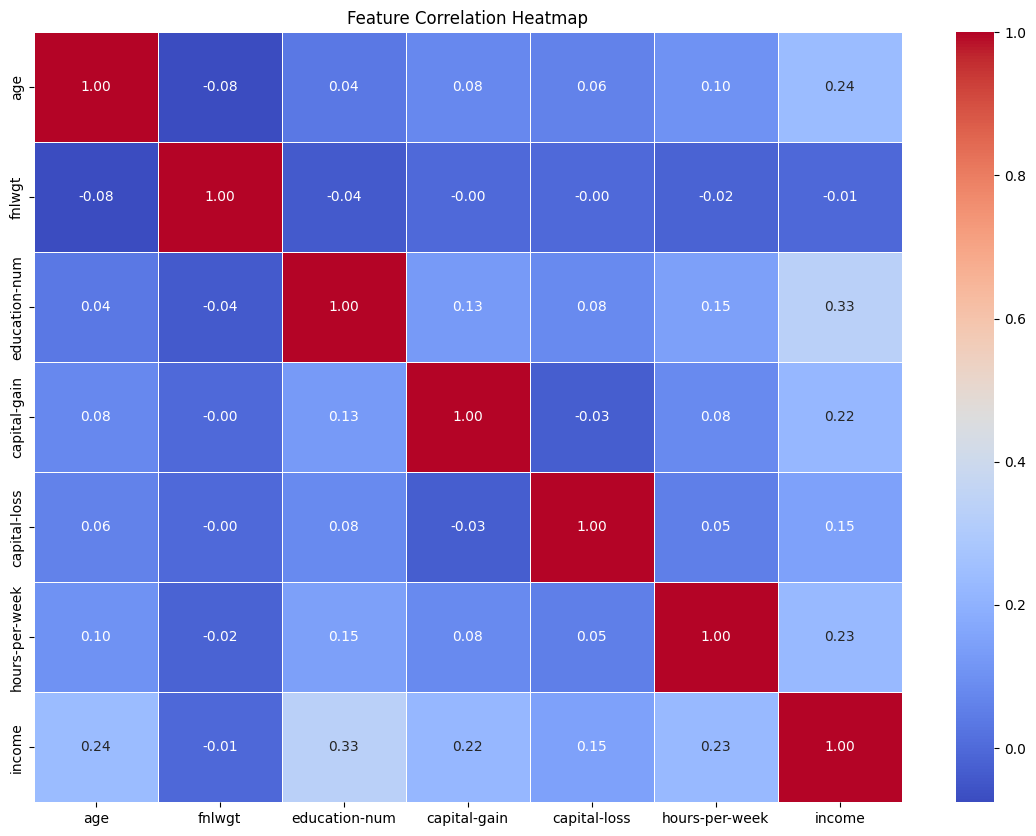

In [132]:
# Plot correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = numerical_col.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

fnlwgt is just for no of individuals for which record represents and education num is present so education is of no need

In [133]:
df.drop(columns=['fnlwgt','education'],inplace=True)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education-num   45222 non-null  int64 
 3   marital-status  45222 non-null  object
 4   occupation      45222 non-null  object
 5   relationship    45222 non-null  object
 6   race            45222 non-null  object
 7   sex             45222 non-null  object
 8   capital-gain    45222 non-null  int64 
 9   capital-loss    45222 non-null  int64 
 10  hours-per-week  45222 non-null  int64 
 11  native-country  45222 non-null  object
 12  income          45222 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 4.5+ MB


Encoding

In [ ]:
categorical = df.select_dtypes(include='object').columns
categorical

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object')

In [138]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical:
    df[col] = le.fit_transform(df[col])

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45222 non-null  int64
 1   workclass       45222 non-null  int64
 2   education-num   45222 non-null  int64
 3   marital-status  45222 non-null  int64
 4   occupation      45222 non-null  int64
 5   relationship    45222 non-null  int64
 6   race            45222 non-null  int64
 7   sex             45222 non-null  int64
 8   capital-gain    45222 non-null  int64
 9   capital-loss    45222 non-null  int64
 10  hours-per-week  45222 non-null  int64
 11  native-country  45222 non-null  int64
 12  income          45222 non-null  int64
dtypes: int64(13)
memory usage: 4.5 MB


In [140]:
df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,5,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,13,2,3,0,4,1,0,0,13,38,0
2,38,2,9,0,5,1,4,1,0,0,40,38,0
3,53,2,7,2,5,0,2,1,0,0,40,38,0
4,28,2,13,2,9,5,2,0,0,0,40,4,0


In [141]:
X = df.drop(columns='income')
y = df['income']

In [153]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [154]:
scaling_col = ['capital-gain','capital-loss','hours-per-week']

In [155]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[scaling_col] = scaler.fit_transform(X_train[scaling_col])
X_test[scaling_col] = scaler.transform(X_test[scaling_col])

In [149]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [157]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return name, acc


KNN Accuracy: 0.8148
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     10193
           1       0.65      0.55      0.60      3374

    accuracy                           0.81     13567
   macro avg       0.75      0.73      0.74     13567
weighted avg       0.81      0.81      0.81     13567



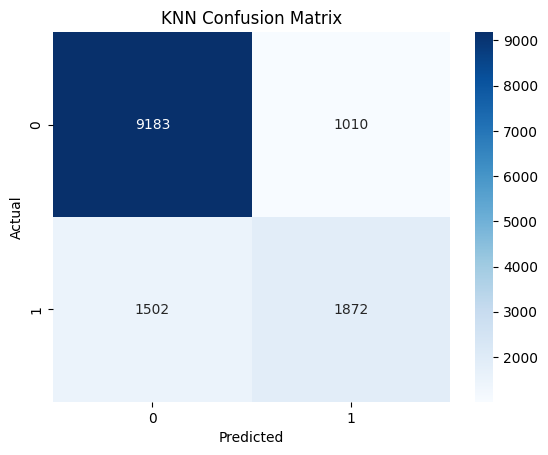


SVM Accuracy: 0.8175
              precision    recall  f1-score   support

           0       0.82      0.97      0.89     10193
           1       0.79      0.36      0.49      3374

    accuracy                           0.82     13567
   macro avg       0.81      0.66      0.69     13567
weighted avg       0.81      0.82      0.79     13567



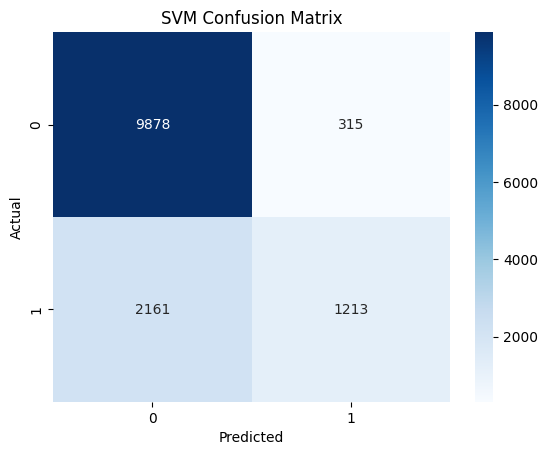


Decision Tree Accuracy: 0.8133
              precision    recall  f1-score   support

           0       0.87      0.88      0.88     10193
           1       0.63      0.62      0.62      3374

    accuracy                           0.81     13567
   macro avg       0.75      0.75      0.75     13567
weighted avg       0.81      0.81      0.81     13567



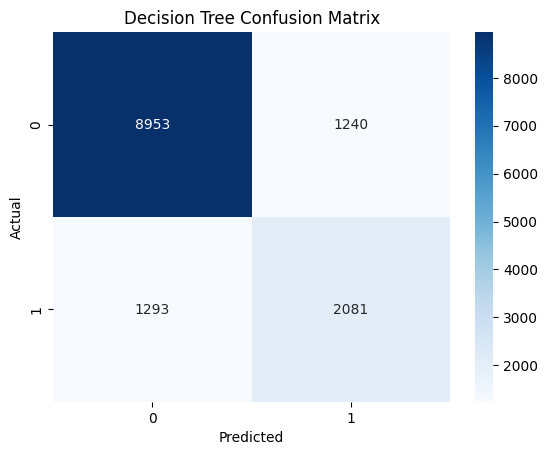


Random Forest Accuracy: 0.8502
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     10193
           1       0.73      0.64      0.68      3374

    accuracy                           0.85     13567
   macro avg       0.81      0.78      0.79     13567
weighted avg       0.85      0.85      0.85     13567



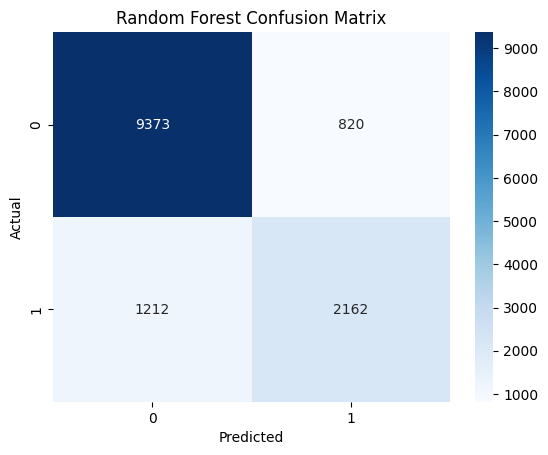


Gradient Boosting Accuracy: 0.8631
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     10193
           1       0.79      0.61      0.69      3374

    accuracy                           0.86     13567
   macro avg       0.84      0.78      0.80     13567
weighted avg       0.86      0.86      0.86     13567



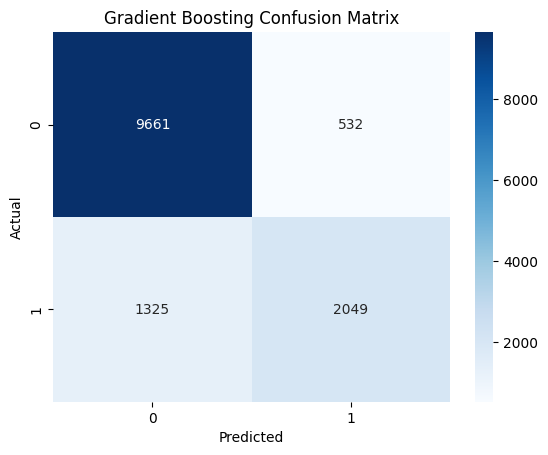


Naive Bayes Accuracy: 0.7967
              precision    recall  f1-score   support

           0       0.81      0.95      0.88     10193
           1       0.69      0.33      0.45      3374

    accuracy                           0.80     13567
   macro avg       0.75      0.64      0.66     13567
weighted avg       0.78      0.80      0.77     13567



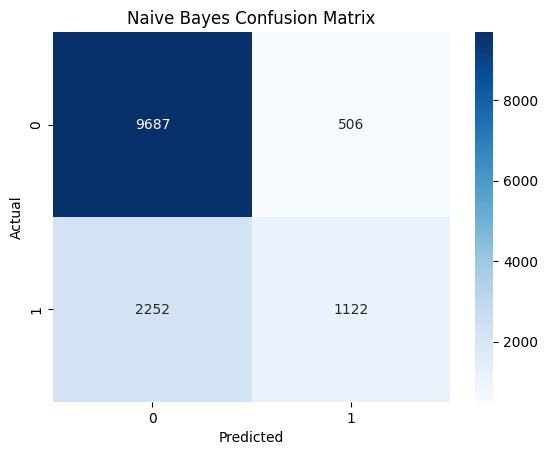

In [158]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

results = []

results.append(evaluate_model('KNN', KNeighborsClassifier()))
results.append(evaluate_model('SVM', SVC()))
results.append(evaluate_model('Decision Tree', DecisionTreeClassifier()))
results.append(evaluate_model('Random Forest', RandomForestClassifier()))
results.append(evaluate_model('Gradient Boosting', GradientBoostingClassifier()))
results.append(evaluate_model('Naive Bayes', GaussianNB()))


C:\Users\acer\AppData\Local\Temp\ipykernel_13320\2929971980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x='Accuracy', y='Model', palette='mako')


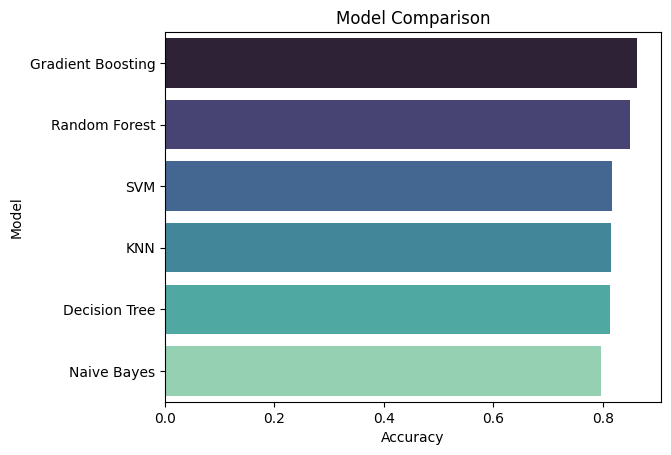

In [163]:
result_df = pd.DataFrame(results, columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
sns.barplot(data=result_df, x='Accuracy', y='Model', palette='mako')
plt.title('Model Comparison')
plt.show()


In [164]:
result_df

,Model,Accuracy
4,Gradient Boosting,0.863124
3,Random Forest,0.850225
1,SVM,0.817498
0,KNN,0.814845
2,Decision Tree,0.813297
5,Naive Bayes,0.796713
